## **Cat and Dog Audio Recognition Dataset**

This dataset contains audio recordings in **WAV format** for two classes: **cat** and **dog**. It is designed for binary audio classification tasks.

### **Dataset Composition**

* **Cat Class**

  * 164 WAV files
  * Total duration: **1323 seconds**

* **Dog Class**

  * 113 WAV files
  * Total duration: **598 seconds**

#### Observations

* The dataset is **imbalanced**:

  * The *cat* class has more files and significantly more total audio duration.
  * This imbalance should be considered during model training (e.g., class weighting, resampling).

### Source

Dataset available on Kaggle:
[https://www.kaggle.com/datasets/mmoreaux/audio-cats-and-dogs](https://www.kaggle.com/datasets/mmoreaux/audio-cats-and-dogs)



Library installation without cuda

##### Run this on the terminal
pip install --upgrade pip setuptools wheel

pip install -r requirements.txt


In [1]:
print("Hello, World!")

Hello, World!


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import os
import IPython.display as ipd
import librosa
import soundfile as sf
import numpy as np

In [3]:
cats_path= r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\Mixed\cats"
dogs_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\Mixed\dogs"

In [4]:

ipd.Audio(os.path.join(dogs_path, "dog_barking_1.wav"))

In [5]:
ipd.Audio(os.path.join(cats_path, "cat_1.wav"))

# **EDA**

##### **1. Audio Length Analysis**

Before training the neural network, it is necessary to analyze the duration of all audio files in the dataset. This allows us to determine whether they have consistent lengths or if there is variability between samples.

Since fully connected neural networks require fixed-size input vectors, all audio samples must have the same length. If differences are found, preprocessing techniques such as padding or trimming will be applied to standardize their size.

This step ensures that the model receives uniform input dimensions during training.


In [6]:
wav, sr = librosa.load(os.path.join(dogs_path, "dog_barking_1.wav"))

c:\Users\Ale\Documents\Lab01\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
print(wav)

[ 0.0025185   0.00160873 -0.00055055 ... -0.01442812 -0.01685726
 -0.01085605]


In [8]:
#Sampling Rate
print(sr)

22050


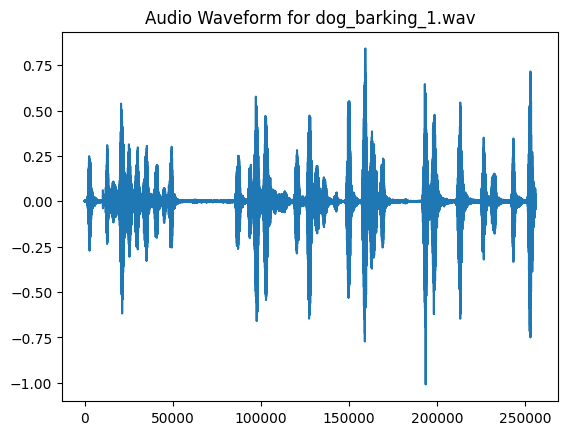

In [9]:
plt.title("Audio Waveform for dog_barking_1.wav")
plt.plot(wav)
plt.show()

In [10]:
# Using the sample rate and the total signal size, the audio length can be calculated.
long_audio = len(wav)/sr
print("The audio length in seconds is:", long_audio)

The audio length in seconds is: 11.6


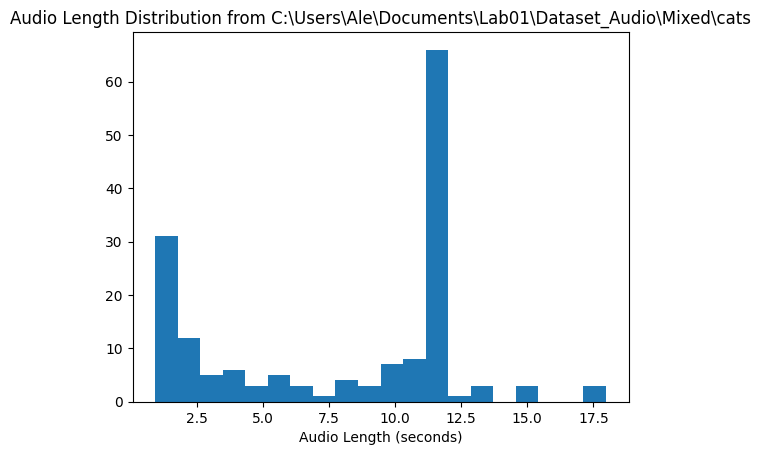

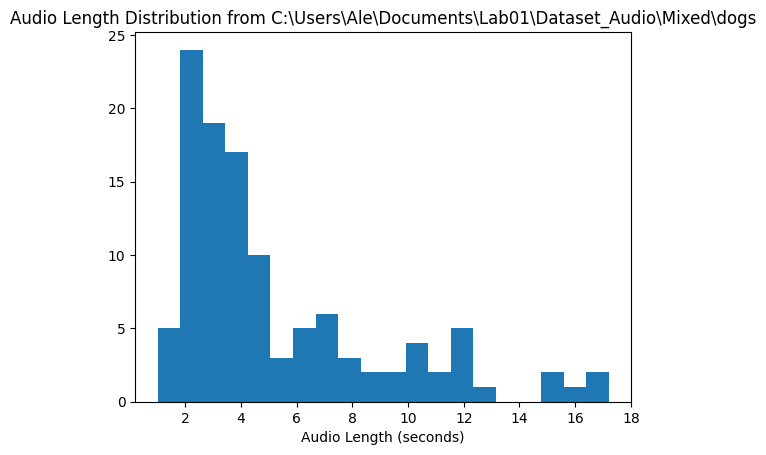

The total length of the cat audio files is: 1323.8999092970525 seconds.
The total length of the dog audio files is: 598.4407256235827 seconds.


In [11]:
def length_of_audio(path):
    "This function is used to calculate the length of audio files in seconds and plot a histogram of the lengths."
    long_audio = []
    for i in os.listdir(path):
        wav, sr = librosa.load(os.path.join(path, i))
        long_audio.append(len(wav)/sr)

    plt.title(f"Audio Length Distribution from {path}")
    plt.hist(long_audio, bins=20)
    plt.xlabel("Audio Length (seconds)")
    plt.show()
    
    total_long_audio = sum(long_audio)

    return long_audio, total_long_audio

long_audio_cats, total_long_audio_cats = length_of_audio(cats_path)
long_audio_dogs, total_long_audio_dogs = length_of_audio(dogs_path)

print(f"The total length of the cat audio files is: {total_long_audio_cats} seconds.")
print(f"The total length of the dog audio files is: {total_long_audio_dogs} seconds.")


In [22]:
def delete_silence(path, output_path):
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    for file in os.listdir(path):
        if file.endswith(".wav"):
            wav, sr = librosa.load(os.path.join(path, file))
            intervals = librosa.effects.split(wav, top_db=25)
            wav_clean = np.concatenate(
                [wav[start:end] for start, end in intervals]
            )
            # Save cleaned audio
            sf.write(os.path.join(output_path, file), wav_clean, sr)

    return f"Audio files with deleted silence have been saved in {output_path}."


no_silence_cats_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\no_silence\cats"
delete_silence(cats_path, no_silence_cats_path)
no_silence_dogs_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\no_silence\dogs"
delete_silence(dogs_path, no_silence_dogs_path)


'Audio files with deleted silence have been saved in C:\\Users\\Ale\\Documents\\Lab01\\Dataset_Audio\\no_silence\\dogs.'

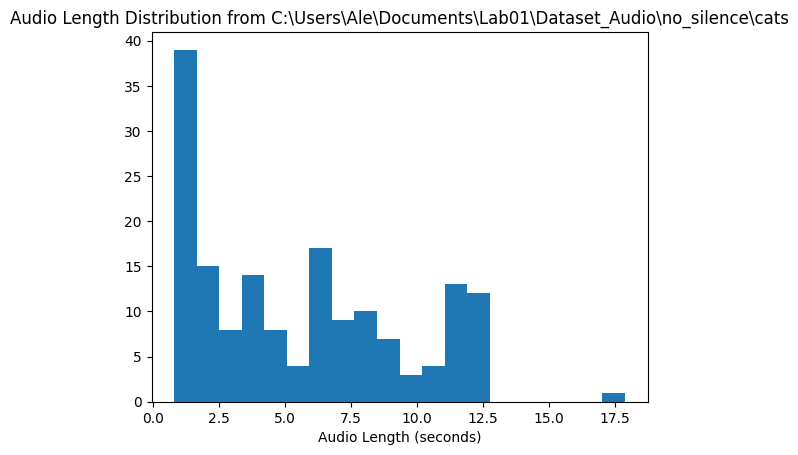

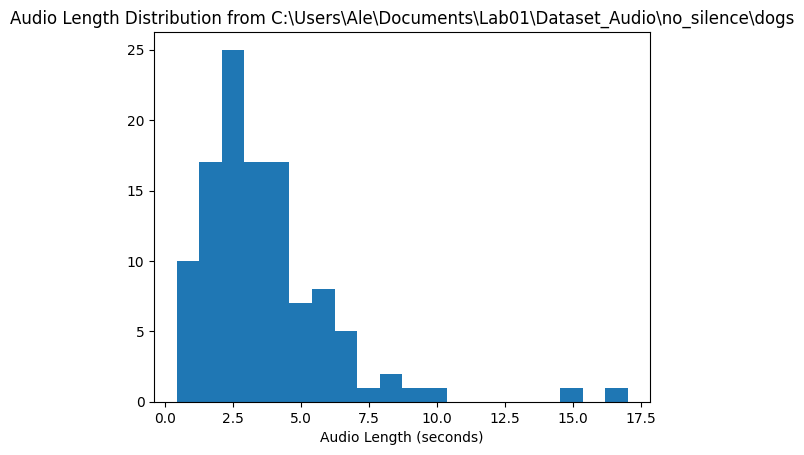

The total length of the cat audio files is: 909.5516099773241 seconds.
The total length of the dog audio files is: 417.9467120181406 seconds.


In [23]:
long_audio_cats, total_long_audio_cats = length_of_audio(no_silence_cats_path)
long_audio_dogs, total_long_audio_dogs = length_of_audio(no_silence_dogs_path)

print(f"The total length of the cat audio files is: {total_long_audio_cats} seconds.")
print(f"The total length of the dog audio files is: {total_long_audio_dogs} seconds.")

In [24]:
ipd.Audio(os.path.join(no_silence_cats_path, "cat_1.wav"))

In [25]:
ipd.Audio(os.path.join(cats_path, "cat_1.wav"))

In [28]:
ipd.Audio(os.path.join(no_silence_dogs_path, "dog_barking_1.wav"))

In [27]:
ipd.Audio(os.path.join(dogs_path, "dog_barking_1.wav"))


To make the data in the same size first we have to truncated them into 3 seconds pieces

In [29]:
def segment_audio(wav, sr, segment_seconds):
    segment_samples = segment_seconds * sr
    segments = []

    total_samples = len(wav)

    for start in range(0, total_samples, segment_samples):
        end = start + segment_samples
        chunk = wav[start:end]

        if len(chunk) < segment_samples:
            chunk = np.pad(chunk, (0, segment_samples - len(chunk)))

        segments.append(chunk)

    return segments


def segment_audio_files(input_path, output_path, segment_seconds=3):
    if not os.path.exists(output_path):
        os.makedirs(output_path)

    for file in os.listdir(input_path):
        if file.endswith(".wav"):
            wav, sr = librosa.load(os.path.join(input_path, file))
            segments = segment_audio(wav, sr, segment_seconds)

            for i, segment in enumerate(segments):
                output_file = f"{os.path.splitext(file)[0]}_segment_{i}.wav"
                sf.write(os.path.join(output_path, output_file), segment, sr)

    return f"Segmented audio files have been saved in {output_path}."

In [31]:
output_segmented_cats_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\cats"
segment_audio_files(no_silence_cats_path, output_segmented_cats_path)

output_segmented_dogs_path = r"C:\Users\Ale\Documents\Lab01\Dataset_Audio\segmented\dogs"
segment_audio_files(no_silence_dogs_path, output_segmented_dogs_path)

'Segmented audio files have been saved in C:\\Users\\Ale\\Documents\\Lab01\\Dataset_Audio\\segmented\\dogs.'

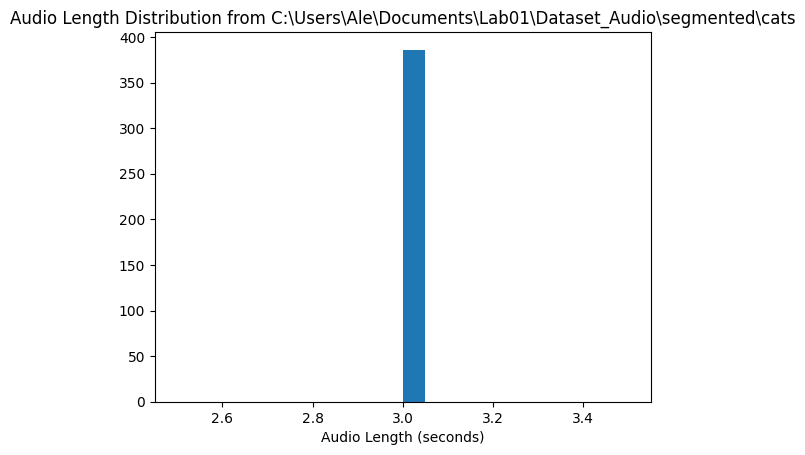

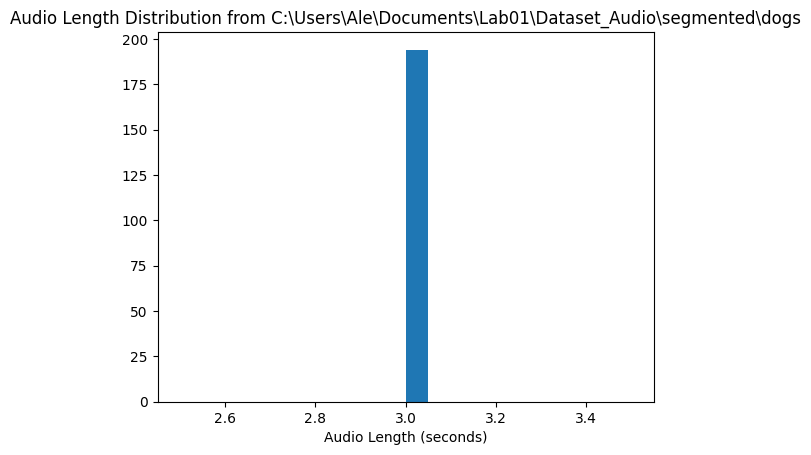

The total length of the cat audio files is: 1158.0 seconds.
The total length of the dog audio files is: 582.0 seconds.


In [32]:
long_audio_cats, total_long_audio_cats = length_of_audio(output_segmented_cats_path)
long_audio_dogs, total_long_audio_dogs = length_of_audio(output_segmented_dogs_path)

print(f"The total length of the cat audio files is: {total_long_audio_cats} seconds.")
print(f"The total length of the dog audio files is: {total_long_audio_dogs} seconds.")